# DI504 FINAL PROJECT :  Mental Health Text Classification

The aim of this notebook is to run the pipeline.

This notebook  the full pipeline by calling functions defined in **src/**. Implementation logic is written in **src/**.


## Section 1 — Imports, Seeds, Environment Check

In [7]:
## IMPORTS
import sys

if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive")
# my root project folder inside google drive
    sys.path.append('/content/drive/MyDrive/di504')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sklearn

from src.utils.seeding import set_global_seed
from config import *


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
## ENVIRONMENT CHECK
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU")


2.11.0+cu128
True
NVIDIA A100-SXM4-40GB


In [9]:
## SET THE SEEDS

set_global_seed(42)

In [10]:
# this is for Colab
!pip install -q optuna nlpaug
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## Section 2 — Load Dataset

In [11]:
from src.data.load import load_raw_data, encode_labels
df = load_raw_data(RAW_DATA_PATH)
encode_labels(df)

df , label_encoder = encode_labels(df)

print(list(label_encoder.classes_))


['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## Section 3 — Raw Data Inspection

In [12]:
print("*"*100)
print(f"dataset size : {df.shape}\n")
print("*"*100)
print(f"field data types: \n{df.dtypes}\n")
print("*"*100)
print(f"examples : \n{df.sample(5)}\n")
print(f"label categories : \n\n{label_encoder.classes_}")

****************************************************************************************************
dataset size : (52681, 3)

****************************************************************************************************
field data types: 
statement         object
status            object
encoded_status     int64
dtype: object

****************************************************************************************************
examples : 
                                               statement      status  \
3008                I'm lazy to complain about it ba ihh      Normal   
44705  i think the wifi on my iphone is broken it wil...      Normal   
50186  Good tracking apps? I've been trying to find a...     Bipolar   
13755  I have recently looked into reddit and found t...  Depression   
32298                  that's your favorite thing to do?      Normal   

       encoded_status  
3008                3  
44705               3  
50186               1  
13755               

## Section 4 — Class Distribution and Descriptive Analysis

In [13]:

print(f"label frequencies: \n{df[LABEL_COLUMN].value_counts()}")
print("*"*100)
print(f"label percentages:\n{df[LABEL_COLUMN].value_counts(normalize=True)*100}\n")


label frequencies: 
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
****************************************************************************************************
label percentages:
status
Normal                  31.022570
Depression              29.240144
Suicidal                20.219814
Anxiety                  7.291054
Bipolar                  5.271350
Stress                   4.910689
Personality disorder     2.044380
Name: proportion, dtype: float64



Text(0.5, 1.0, 'Bar Chart of Label Frequencies')

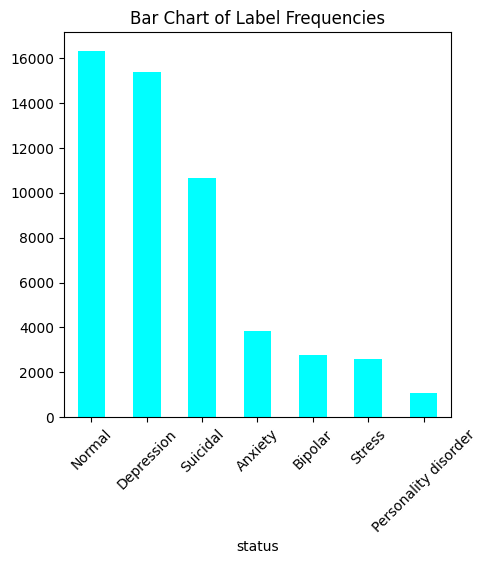

In [14]:
## PLOT LABEL FREQUENCY BAR CHART
fig, ax = plt.subplots(nrows= 1, ncols= 1)
fig.set_size_inches((5,5))
df[LABEL_COLUMN].value_counts().plot(kind = "bar", color = 'cyan', ax= ax)
ax.tick_params(axis='x', labelrotation=45)
ax.set_title("Bar Chart of Label Frequencies")


In [15]:
# Character length stats

char_length = df['statement'].str.len()

word_count = df['statement'].str.split().str.len()

# Overall stats
overall_stats = pd.DataFrame({
    'char_length': char_length.agg(['min', 'max', 'mean', 'std']),
    'word_count': word_count.agg(['min', 'max', 'mean', 'std']),
})
print("Overall statistics:")
print(overall_stats, '\n')

# Per label stats

df['_word_count'] = word_count  # creating temp column for group by
per_class_char = df.groupby('status')['statement'].apply(lambda s: s.str.len().agg(['min', 'max', 'mean', 'std']))
per_class_word = df.groupby('status')['_word_count'].agg(['min', 'max', 'mean', 'std'])

print("Per label character length:")
print(per_class_char, '\n')
print("Per label word count:")
print(per_class_word, '\n')

# The actual question that matters for MAX_LEN=200: what fraction of
# statements would get truncated?
fraction_over_200 = (word_count > 200).mean()
print(f"Fraction of statements exceeding 200 words: {fraction_over_200:.4f} ({fraction_over_200*100:.2f}%)")

df.drop(columns=['_word_count'], inplace=True)  # clean up the temp column

Overall statistics:
       char_length   word_count
min       2.000000     1.000000
max   32759.000000  6300.000000
mean    578.713863   113.158729
std     846.269078   163.735305 

Per label character length:
status                    
Anxiety               min         7.000000
                      max      8539.000000
                      mean      764.681073
                      std       812.378061
Bipolar               min        27.000000
                      max     26163.000000
                      mean      946.074901
                      std       952.510895
Depression            min         3.000000
                      max     19822.000000
                      mean      844.031161
                      std       953.004199
Normal                min         2.000000
                      max      1358.000000
                      mean       90.244447
                      std       120.898909
Personality disorder  min        39.000000
                      max     27

## Section 5 — Text Cleaning: Two Pipelines -  ML, and Sequential

In [16]:
# Two seperate pipelines one ML and one Sequential, each has different preprocessing
# import the functions
# for implementation logic : Please see src.preprocessing
from src.preprocessing.ml_pipeline import clean_text_ml
from src.preprocessing.seq_pipeline import clean_text_seq

# cache the preprocessing data as it takes time to clean up all rows (more than 50000!)
preprocessed_df_cache_file_location =  PROCESSED_DATA_DIR / "preprocessed_df.csv"
if 'statement_ml' not in df.columns:
    if not preprocessed_df_cache_file_location.exists():
        df['statement_ml'] = df['statement'].apply(clean_text_ml)
        df['statement_seq'] = df['statement'].apply(clean_text_seq)

        df.to_csv(preprocessed_df_cache_file_location,index=False)
        print("preprocessed file is written inside /data/processed/preprocessed_df.csv")
    else:
        df = pd.read_csv(str(preprocessed_df_cache_file_location))


    before = len(df)
    df = df.dropna(subset=['statement_ml', 'statement_seq']).reset_index(drop=True)
    df = df[(df['statement_ml'].str.strip() != '') & (df['statement_seq'].str.strip() != '')].reset_index(drop=True)
    print(f"Dropped {before - len(df)} rows with empty statement_ml/statement_seq")


Dropped 0 rows with empty statement_ml/statement_seq


In [17]:
# see some samples

mask = df['statement'].str.contains(r'http|www\.|@|#|<', regex=True, na=False)
df[mask][['statement', 'statement_seq']].sample(5)

,statement,statement_seq
36495,"Update on my phone real quick, it was in my ca...",update on my phone real quick it was in my car...
2472,"Nimemweka #Bwana mbele yangu daima, Kwa kuwa y...",nimemweka <HASHTAG> mbele yangu daima kwa kuwa...
37429,"I need a guidance, mentor, father figure, guar...",i need a guidance mentor father figure guardia...
35503,"Do you ever find your ""symptoms"" change or tra...",do you ever find your symptoms change or trans...
41036,honourable mention to this song about aquarius...,honourable mention to this song about aquarius...


In [18]:
# Word count on cleaned statement_seq, this is proxy for GRU actual input length.
seq_word_count = df['statement_seq'].str.split().str.len()

# Temp column so groupby can aggregate it, dropped at the end.
df['_seq_word_count'] = seq_word_count

# Mean and max word count per class
per_class_seq = df.groupby('status')['_seq_word_count'].agg(['mean', 'max'])

# Per label fraction of statements that would be truncated under MAX_LEN=200.
per_class_truncation = df.groupby('status')['_seq_word_count'].apply(lambda s: (s > 200).mean())

print(per_class_seq)
print("*"*100)
print(per_class_truncation.sort_values(ascending=False))

# Overall truncation rate across the whole dataset.
fraction_over_200_seq = (seq_word_count > 200).mean()
print(f"\nFraction exceeding 200 words (post-cleaning): {fraction_over_200_seq:.4f}")

# Clean up the temp column.
df.drop(columns=['_seq_word_count'], inplace=True)

                            mean   max
status                                
Anxiety               142.219995  1575
Bipolar               174.413036  4787
Depression            167.101072  4238
Normal                 17.080587   255
Personality disorder  178.136490  5410
Stress                113.278530  1597
Suicidal              145.575897  6300
****************************************************************************************************
status
Personality disorder    0.317549
Bipolar                 0.287360
Depression              0.275544
Anxiety                 0.228586
Suicidal                0.224216
Stress                  0.104449
Normal                  0.000185
Name: _seq_word_count, dtype: float64

Fraction exceeding 200 words (post-cleaning): 0.1698


## Section 6 — Train / Val / Test Split

In [19]:
# 60 - 20 - 20 TRAIN VAL TEST SPLIT
# The implementation logic is inside src.data.split file

from src.data.splits import split_data

train_df, val_df , test_df = split_data(df, label_column='encoded_status', random_state = GLOBAL_SEED)



train: (31516, 5), 0.600 of total
val:   (10505, 5), 0.200 of total
test:  (10506, 5), 0.200 of total

train class distribution:
encoded_status
0    0.073137
1    0.052862
2    0.293089
3    0.308510
4    0.020498
5    0.049213
6    0.202691
Name: proportion, dtype: float64

val class distribution:
encoded_status
0    0.073108
1    0.052832
2    0.293099
3    0.308520
4    0.020562
5    0.049215
6    0.202665
Name: proportion, dtype: float64

test class distribution:
encoded_status
0    0.073101
1    0.052922
2    0.293071
3    0.308586
4    0.020464
5    0.049210
6    0.202646
Name: proportion, dtype: float64


## Section 7 — EDA Augmentation on Minority Classes FOR Phase 2

In [20]:
## CREATING Augmented train dataframe for Phase II.
# In phase II, in order to mitigate label imbalance, text augmentation is experimented.
# Here, training dataset is applied with a text augmenation technique and the results are saved in a CSV file
# Please note that this dataframe will not be used during Phase I which is the re-implementation of Ding et.al study.


from src.preprocessing.augment import augment_minority_classes
train_df_augmented_file_path = PROCESSED_DATA_DIR / 'train_df_augmented.csv'
# since this is a heavy operation run once and cache the results in a csv file
if not train_df_augmented_file_path.exists():

    train_df_augmented = augment_minority_classes(train_df, minority_classes= MINORITY_CLASSES_FOR_AUGMENTATION, label_column= LABEL_COLUMN)
    train_df_augmented.to_csv(train_df_augmented_file_path,index=False)
else:
    train_df_augmented = pd.read_csv(train_df_augmented_file_path)

## Section 8 — TF-IDF Vectorization

In [21]:
## FEATURE EXTRACTION, TFIDF with ngram range (1,2)

from src.preprocessing.vectorize import fit_tfidf, transform_tfidf
tfidf_vectorizer, X_train_tfidf = fit_tfidf(train_df[PREPROCESS_POSTS_ML])
X_val_tfidf = transform_tfidf(tfidf_vectorizer, val_df[PREPROCESS_POSTS_ML])
X_test_tfidf = transform_tfidf(tfidf_vectorizer, test_df[PREPROCESS_POSTS_ML])

X_train_tfidf.shape[1]

number of features : {len(tfidf_vec.get_feature_names_out())}
sample from the features : ['anxiety depression', 'anymore anymore', 'anymore want', 'best friend', 'commit suicide', 'day day', 'days ago', 'depression anxiety', 'die want', 'dont feel']


1000

In [22]:
print(X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)
print([f for f in tfidf_vectorizer.get_feature_names_out() if ' ' in f][:5])

(31516, 1000) (10505, 1000) (10506, 1000)
['anxiety depression', 'anymore anymore', 'anymore want', 'best friend', 'commit suicide']


## Section 9 — Logistic Regression with Manual Grid Search

In [23]:
## TARGET LABELS for train / val / test (used by grid_search for fit and scoring)

y_train = train_df['encoded_status']
y_val = val_df['encoded_status']
y_test = test_df['encoded_status']

print(y_train.shape, y_val.shape, y_test.shape)
print(y_train.value_counts(normalize=True).sort_index())

(31516,) (10505,) (10506,)
encoded_status
0    0.073137
1    0.052862
2    0.293089
3    0.308510
4    0.020498
5    0.049213
6    0.202691
Name: proportion, dtype: float64


In [ ]:
### GRID SEARCH 
from src.models.baseline import build_logistic_regression, LR_PARAM_GRID
from src.training.tune_baseline import grid_search
best_lr, best_lr_params, best_lr_val_f1 = grid_search(build_logistic_regression,LR_PARAM_GRID,X_train_tfidf,y_train, X_val_tfidf, y_val)

Trying 12 combinations...
{'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7131
{'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.6884
{'C': 0.1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7130
{'C': 0.1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.6886
{'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7331
{'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.7395


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'C': 1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7231
{'C': 1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.7394
{'C': 10, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7261
{'C': 10, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.7386


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'C': 10, 'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 1000} -> weighted F1: 0.7075
{'C': 10, 'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000} -> weighted F1: 0.7389


In [25]:
## print out the best model and best parameteres

print(f"best logistic regression parameters: {best_lr_params}\nbest f1 score : {best_lr_val_f1}")

best logistic regression parameters: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'max_iter': 1000}
best f1 score : 0.7394828973688187


## Section 10 — GRU Preprocessing: Vocab, Sequences, DataLoaders

In [26]:
from src.models.gru import build_vocab, text_to_sequence, TextDataset
from torch.utils.data import Dataset, DataLoader

# building the vocabulary
vocab = build_vocab(train_df[PREPROCESS_POSTS_SEQ])

# fixing text to 200 for each train , val and test. The data is stored inside dataframes
train_df["fixed_seq"] = train_df[PREPROCESS_POSTS_SEQ].apply(text_to_sequence,vocab = vocab)
val_df["fixed_seq"] = val_df[PREPROCESS_POSTS_SEQ].apply(text_to_sequence,vocab = vocab)
test_df["fixed_seq"] = test_df[PREPROCESS_POSTS_SEQ].apply(text_to_sequence,vocab = vocab)

# creating Dataset for train, val and test in order to create Dataloader
train_Dataset = TextDataset(sequences=train_df["fixed_seq"].tolist(),labels = train_df["encoded_status"].tolist())
val_Dataset = TextDataset(sequences=val_df["fixed_seq"].tolist(),labels = val_df["encoded_status"].tolist())
test_Dataset = TextDataset(sequences=test_df["fixed_seq"].tolist(),labels = test_df["encoded_status"].tolist())

train_dataloader = DataLoader(
    dataset=train_Dataset,
    batch_size=GRU_BATCH_SIZE,
    shuffle=True,
)

In [27]:
seqs, labels = next(iter(train_dataloader))
print(seqs.shape, labels.shape)  # expect torch.Size([16, 200]) torch.Size([16])

torch.Size([16, 200]) torch.Size([16])


## Section 11 — GRU Model Definition, and Small Test without HyperParameter tuning

In [ ]:
# This cell is just an architecture smoke test.
# actual training happens inside Section 13
#  with hyperparameters chosen by the search
from src.models.gru import GRUClassifier
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"device is {device}")
model = GRUClassifier(vocab_size=10000, embedding_dim=200, hidden_dim=256).to(device)
sequences, labels = next(iter(train_dataloader))
sequences = sequences.to(device)

logits = model(sequences)
print("expect torch.Size([16, 7])")
print(f"actual shape : {logits.shape}")

device is cuda
expect torch.Size([16, 7])
actual shape : torch.Size([16, 7])


## Section 12 — GRU Training: Optuna Search and Adam Optimizer

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from src.training.tune_gru import run_gru_search, train_final_gru
import optuna.visualization.matplotlib as ov

# compute class_weights for CrossEntropyLoss — typically
# sklearn.utils.class_weight.compute_class_weight('balanced', classes=..., y=train_labels),
# converted to a torch.float tensor on `device`.
class_weights_np = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['encoded_status']),
    y=train_df['encoded_status']
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print(class_weights) # there are 7

tensor([1.9533, 2.7025, 0.4874, 0.4631, 6.9695, 2.9028, 0.7048],
       device='cuda:0')


In [ ]:
## RUN HYPERPARAMETER TESTING
best_params, study = run_gru_search(
    train_Dataset, val_Dataset, vocab_size=GRU_VOCAB_SIZE,
    class_weights=class_weights, device=device, n_trials=10
)



[I 2026-06-21 07:11:23,326] A new study created in memory with name: no-name-d6d0f8fa-6ee1-4942-84c7-1000b874cc44
[I 2026-06-21 07:14:04,482] Trial 0 finished with value: 0.7653760228576113 and parameters: {'embedding_dim': 169, 'hidden_dim': 575, 'lr': 0.00027398560064478833, 'epochs': 9}. Best is trial 0 with value: 0.7653760228576113.
[I 2026-06-21 07:16:36,703] Trial 1 finished with value: 0.7654293785769284 and parameters: {'embedding_dim': 228, 'hidden_dim': 395, 'lr': 0.00018900106663710588, 'epochs': 9}. Best is trial 1 with value: 0.7654293785769284.
[I 2026-06-21 07:19:18,910] Trial 2 finished with value: 0.765551063201958 and parameters: {'embedding_dim': 246, 'hidden_dim': 705, 'lr': 0.0002279382816537333, 'epochs': 8}. Best is trial 2 with value: 0.765551063201958.
[I 2026-06-21 07:21:56,690] Trial 3 finished with value: 0.7611234680282841 and parameters: {'embedding_dim': 219, 'hidden_dim': 621, 'lr': 0.00023455827269243772, 'epochs': 8}. Best is trial 2 with value: 0.765

Best params: {'embedding_dim': 246, 'hidden_dim': 705, 'lr': 0.0002279382816537333, 'epochs': 8}
Best val weighted F1: 0.765551063201958


Optuna find out that best parameters for the defined settings are;

Best embedding dimension is 246

Best hidden layer size is 705

Best lr is 0.0002279382816537333

and best epoch no is 8

/tmp/ipykernel_1054/3360300653.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ov.plot_optimization_history(study)
/tmp/ipykernel_1054/3360300653.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ov.plot_param_importances(study)
/tmp/ipykernel_1054/3360300653.py:4: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ov.plot_parallel_coordinate(study)


<Axes: title={'center': 'Parallel Coordinate Plot'}>

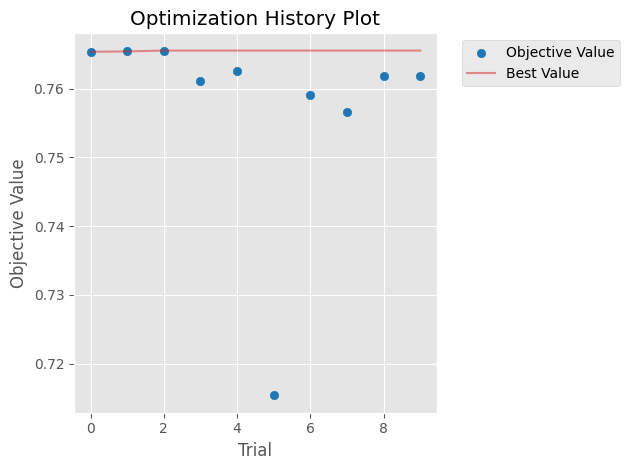

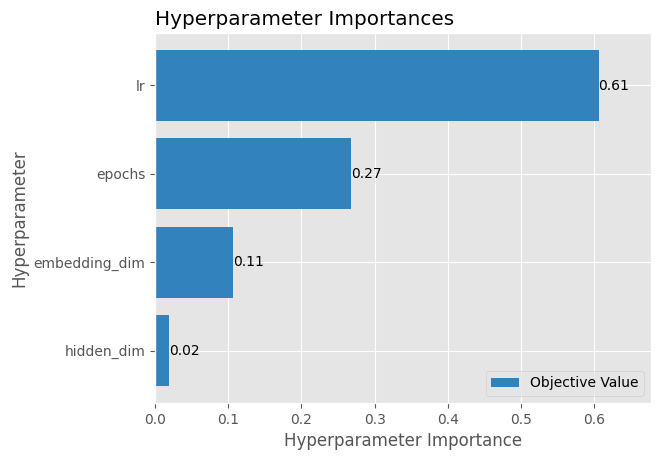

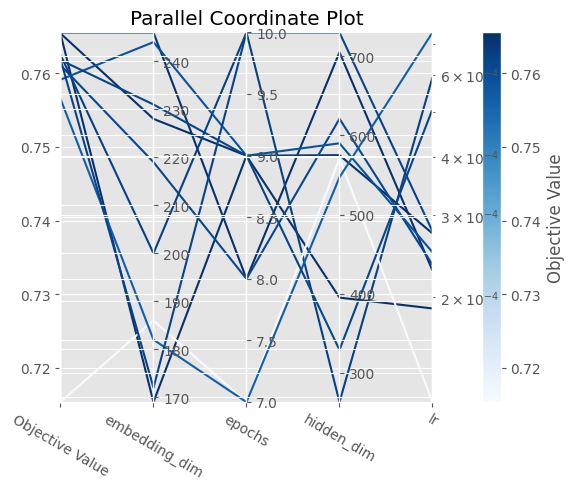

In [ ]:
## OPTUNE VISUALIZATIONS
## These plots are providedd by optuna without any loss so I plot them 
ov.plot_optimization_history(study)
ov.plot_param_importances(study)
ov.plot_parallel_coordinate(study)

In [ ]:
# WITH BEST PARAMETERS, TRAIN GRU with best parameters


gru_adam_model, train_losses_adam, val_losses_adam = train_final_gru(
    best_params, train_Dataset, val_Dataset, vocab_size=GRU_VOCAB_SIZE,
    class_weights=class_weights, device=device, optimizer_name="adam"
)

Epoch 1/8 - train_loss: 1.7854, val_loss: 1.3949, val_f1: 0.5043
Epoch 2/8 - train_loss: 1.2050, val_loss: 0.9717, val_f1: 0.6810
Epoch 3/8 - train_loss: 0.7800, val_loss: 0.7775, val_f1: 0.7390
Epoch 4/8 - train_loss: 0.5632, val_loss: 0.7780, val_f1: 0.7593
Epoch 5/8 - train_loss: 0.4188, val_loss: 0.7763, val_f1: 0.7646
Epoch 6/8 - train_loss: 0.3215, val_loss: 0.8799, val_f1: 0.7654
Epoch 7/8 - train_loss: 0.2476, val_loss: 0.8561, val_f1: 0.7703
Epoch 8/8 - train_loss: 0.1934, val_loss: 1.0013, val_f1: 0.7685


## Section 13 — GRU with AdamW

In [ ]:
# Same best_params as Section 14, only the optimizer changes. 
# This is done to see the optimizer's effect by keeping everything constant (ceteris paribus) for a fair comparison.
gru_adamw_model, train_losses_adamw, val_losses_adamw = train_final_gru(
    best_params, train_Dataset, val_Dataset, vocab_size=GRU_VOCAB_SIZE,
    class_weights=class_weights, device=device, optimizer_name="adamw"
)

Epoch 1/8 - train_loss: 1.7887, val_loss: 1.4229, val_f1: 0.4889
Epoch 2/8 - train_loss: 1.1113, val_loss: 0.8631, val_f1: 0.7064
Epoch 3/8 - train_loss: 0.7109, val_loss: 0.7613, val_f1: 0.7512
Epoch 4/8 - train_loss: 0.5278, val_loss: 0.7437, val_f1: 0.7653
Epoch 5/8 - train_loss: 0.4003, val_loss: 0.7713, val_f1: 0.7696
Epoch 6/8 - train_loss: 0.3130, val_loss: 0.8402, val_f1: 0.7744
Epoch 7/8 - train_loss: 0.2409, val_loss: 0.8730, val_f1: 0.7717
Epoch 8/8 - train_loss: 0.1914, val_loss: 0.9666, val_f1: 0.7737


## Section 14 — GRU Evaluation

In [ ]:

from src.evaluation.evaluate_pytorch import evaluate_pytorch_model
from src.utils.viz import plot_confusion_matrix, plot_roc_curves, plot_training_curves
from torch.utils.data import DataLoader

# test_loader wasn't built yet in earlier cells — only train_dataloader was.
# shuffle=False here, since order doesn't matter for evaluation and shuffling
# would just make debugging/inspection harder for no benefit.

# use dataloader to create test loader. Shuffle false
test_loader = DataLoader(test_Dataset, batch_size=GRU_BATCH_SIZE, shuffle=False)

# run GRU model with the same test set for optimizer = ADAM and = ADAMW
gru_adam_results = evaluate_pytorch_model(
    gru_adam_model, test_loader, device, CLASS_NAMES, use_attention_mask=False
)
gru_adamw_results = evaluate_pytorch_model(
    gru_adamw_model, test_loader, device, CLASS_NAMES, use_attention_mask=False
)


In [ ]:

# PRINT RESULTS
print("Adam:  weighted F1 =", gru_adam_results['weighted_f1'], gru_adam_results['weighted_f1_ci'])
print("AdamW: weighted F1 =", gru_adamw_results['weighted_f1'], gru_adamw_results['weighted_f1_ci'])



Adam:  weighted F1 = 0.7582760453154338 (np.float64(0.7495452380907555), np.float64(0.7664578813988311))
AdamW: weighted F1 = 0.7610633536970324 (np.float64(0.7524584142719438), np.float64(0.7687405776196512))


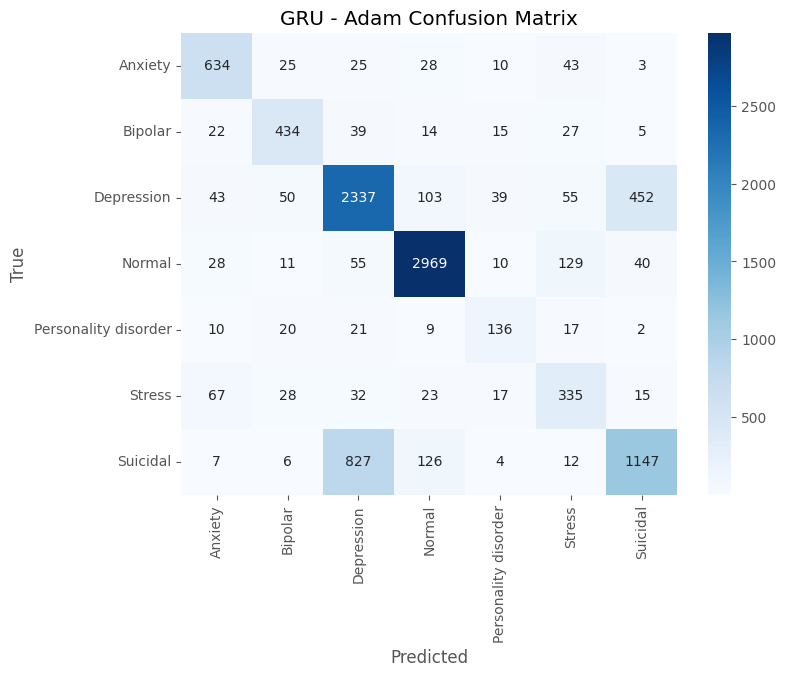

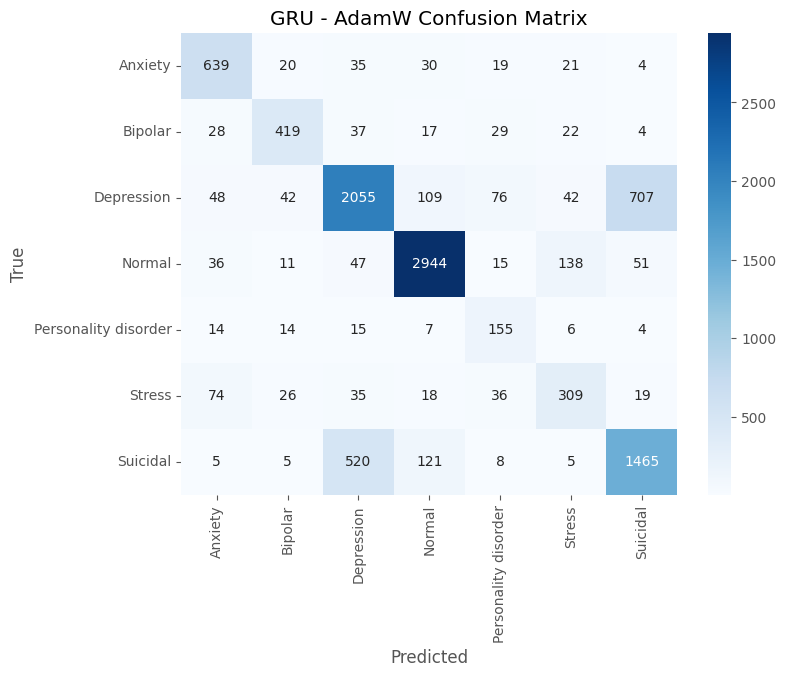

In [ ]:
# CONFUSION MATRIX


plot_confusion_matrix(gru_adam_results['confusion_matrix'], CLASS_NAMES, title="GRU - Adam Confusion Matrix")
plot_confusion_matrix(gru_adamw_results['confusion_matrix'], CLASS_NAMES, title="GRU - AdamW Confusion Matrix")



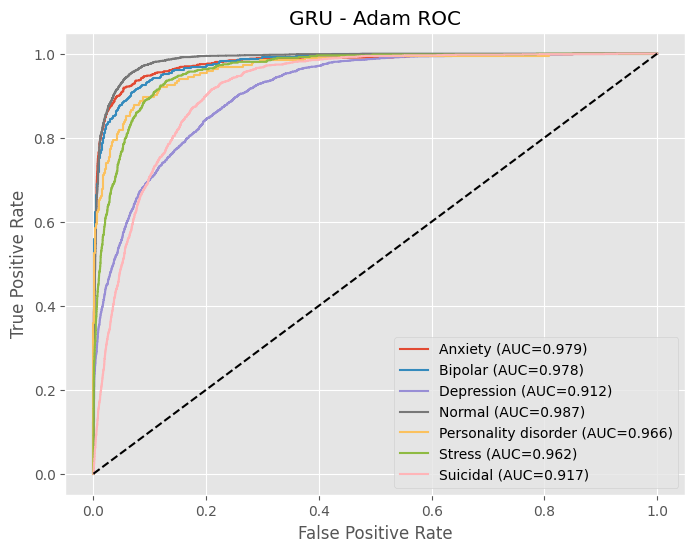

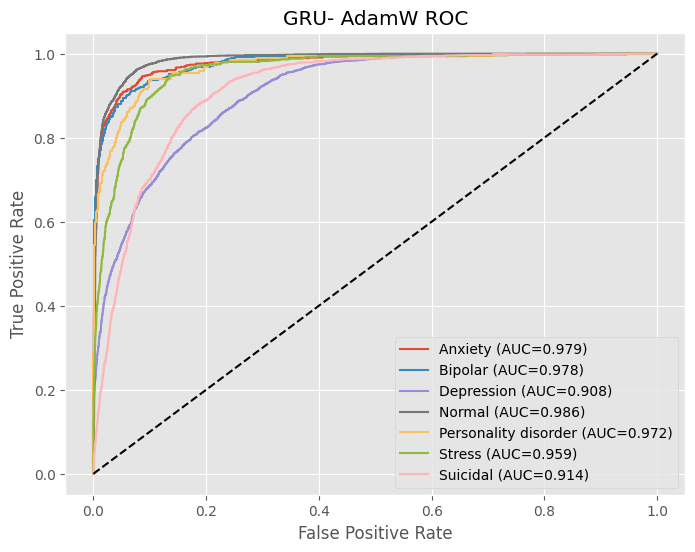

In [ ]:
# ROC CURVE for BOTH ADAM and ADAMW
plot_roc_curves(gru_adam_results['y_true'], gru_adam_results['y_proba'], CLASS_NAMES, title="GRU - Adam ROC")
plot_roc_curves(gru_adamw_results['y_true'], gru_adamw_results['y_proba'], CLASS_NAMES, title="GRU- AdamW ROC")



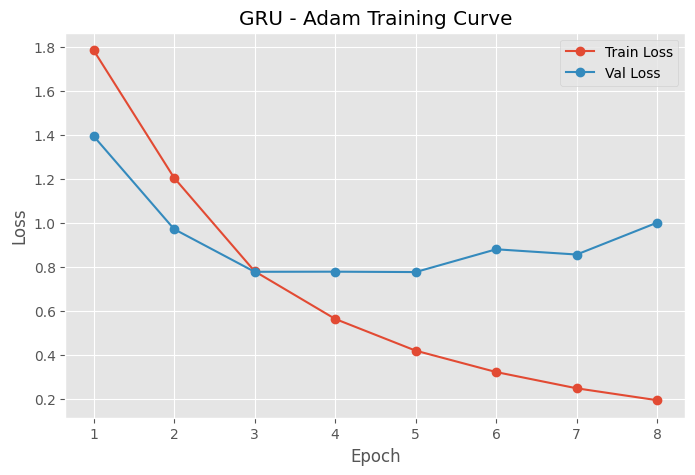

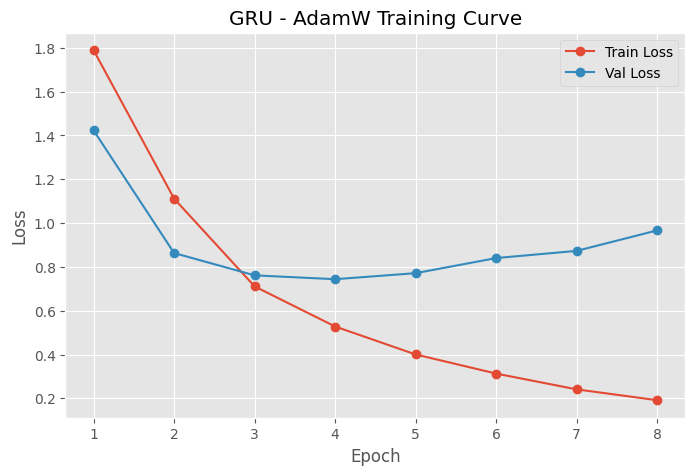

In [ ]:
# TRAIN VS LOSS CURVES GRU
plot_training_curves(train_losses_adam, val_losses_adam, title="GRU - Adam Training Curve")
plot_training_curves(train_losses_adamw, val_losses_adamw, title="GRU - AdamW Training Curve")

---
### Sections 15-17 (ALBERT preprocessing, fine-tuning, evaluation) live in "albert_finetuning.ipynb", run separately on Colab A100. 

---

## Section 18 - Phase 2 — Class Imbalance Mitigation Experiment with EDA Augmentation

This is the first Phase 2 experiment, try to answer question whether EDA text augmentation 

actually mprove performance on the minority classes, holding everything else fixed? Reuses

"best_params" from Section 14s Optuna search and "train_df_augmented" from

Section 8. 

No new hyperparameter search here, since the goal is to isolate

augmentation as the one variable that changed versus Phase 1's GRU+Adam model.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from src.models.gru import build_vocab, text_to_sequence, TextDataset
from src.training.tune_gru import train_final_gru
from src.evaluation.evaluate_pytorch import evaluate_pytorch_model

In [ ]:
# Rebuild vocab from train_df_augmented, NOT train_df. 
# augmentation changes word frequencies, so the augmented training set deserves its own vocab.

## TRAIN DF AUGMENED is built in SECTION 8
vocab_augmented = build_vocab(train_df_augmented[PREPROCESS_POSTS_SEQ], vocab_size=GRU_VOCAB_SIZE)

train_df_augmented["fixed_seq"] = train_df_augmented[PREPROCESS_POSTS_SEQ].apply(
    text_to_sequence, vocab=vocab_augmented
)

train_dataset_augmented = TextDataset(
    sequences=train_df_augmented["fixed_seq"].tolist(),
    labels=train_df_augmented["encoded_status"].tolist()
)
## since vocab is different, validation dataframe should be updated as well!!
val_df["fixed_seq_augmented"] = val_df[PREPROCESS_POSTS_SEQ].apply(text_to_sequence, vocab=vocab_augmented)
val_Dataset_augmented = TextDataset(
    sequences=val_df["fixed_seq_augmented"].tolist(),
    labels=val_df["encoded_status"].tolist()
)

## TRAIN GRU with AUGMENTED DATA, USE BEST PARAMETERS FROM EARLIER HYPERPARAMETER TUNING
gru_adam_augmented_model, train_losses_aug, val_losses_aug = train_final_gru(
    best_params, train_dataset_augmented, val_Dataset_augmented, vocab_size=GRU_VOCAB_SIZE,
    class_weights=class_weights_augmented, device=device, optimizer_name="adam"
)



Epoch 1/8 - train_loss: 1.3498, val_loss: 0.8076, val_f1: 0.6678
Epoch 2/8 - train_loss: 0.5145, val_loss: 0.7106, val_f1: 0.7392
Epoch 3/8 - train_loss: 0.3113, val_loss: 0.6575, val_f1: 0.7709
Epoch 4/8 - train_loss: 0.2242, val_loss: 0.6786, val_f1: 0.7646
Epoch 5/8 - train_loss: 0.1713, val_loss: 0.7222, val_f1: 0.7730
Epoch 6/8 - train_loss: 0.1257, val_loss: 0.8678, val_f1: 0.7686
Epoch 7/8 - train_loss: 0.0848, val_loss: 0.9668, val_f1: 0.7650
Epoch 8/8 - train_loss: 0.0565, val_loss: 1.0595, val_f1: 0.7640


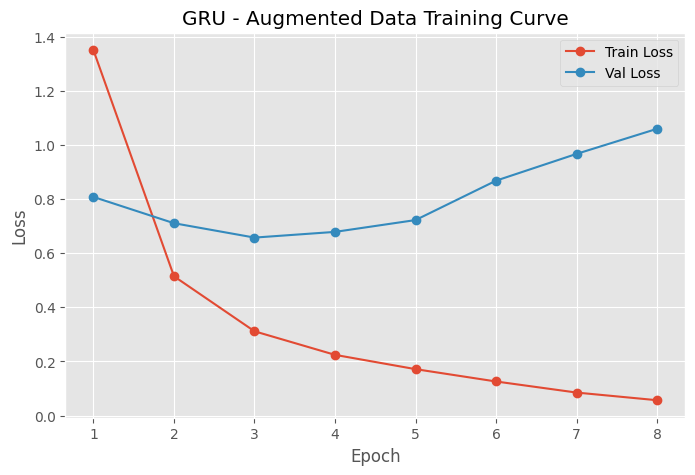

In [ ]:
plot_training_curves(train_losses_aug, val_losses_aug, title="GRU - Augmented Data Training Curve")

In [ ]:
## SINCE VOCAB CHANGED, TEST DATASET IS UPDATED AS WELL WITH NEW VOCAB
test_df["fixed_seq_augmented"] = test_df[PREPROCESS_POSTS_SEQ].apply(text_to_sequence, vocab=vocab_augmented)

test_Dataset_augmented = TextDataset(
    sequences=test_df["fixed_seq_augmented"].tolist(),
    labels=test_df["encoded_status"].tolist()
)

test_loader_augmented = DataLoader(test_Dataset_augmented, batch_size=GRU_BATCH_SIZE, shuffle=False)

## EVALULATING GRU RESULT WITH TESTED
gru_adam_augmented_results = evaluate_pytorch_model(
    gru_adam_augmented_model, test_loader_augmented, device, CLASS_NAMES, use_attention_mask=False
)

print(gru_adam_augmented_results['weighted_f1'])

0.7714907114941405


In [ ]:
# Class weights recomputed from train_df_augmented's labels, since
# augmentation shifted the class counts 
# reusing Phase 1's weights here
# would  confuse the new class balance.
class_weights_augmented_np = compute_class_weight(
    'balanced',
    classes=np.unique(train_df_augmented['encoded_status']),
    y=train_df_augmented['encoded_status']
)
class_weights_augmented = torch.tensor(class_weights_augmented_np, dtype=torch.float).to(device)
print(class_weights_augmented)



tensor([1.1383, 1.1383, 0.7872, 0.7479, 1.1383, 1.1383, 1.1383],
       device='cuda:0')


In [67]:
print("Phase 1 (unaugmented) weighted F1:", gru_adam_results['weighted_f1'])
print("Phase 2 (augmented)   weighted F1:", gru_adam_augmented_results['weighted_f1'])


Phase 1 (unaugmented) weighted F1: 0.7582760453154338
Phase 2 (augmented)   weighted F1: 0.7714907114941405


In [ ]:
## FINAL COMPARISON with the ORIGINAL DATASET ##
# per-label F1 for the 4 augmented
# classes specifically, not the aggregate metric.
print("\nPer-class F1 comparison (Phase 1 vs Phase 2):")
for cls in MINORITY_CLASSES_FOR_AUGMENTATION:
    p1_f1 = gru_adam_results['classification_report'][cls]['f1-score']
    p2_f1 = gru_adam_augmented_results['classification_report'][cls]['f1-score']
    print(f"{cls:25s} Phase 1: {p1_f1:.4f}  Phase 2: {p2_f1:.4f}  Δ: {p2_f1 - p1_f1:+.4f}")


Per-class F1 comparison (Phase 1 vs Phase 2):
Personality disorder      Phase 1: 0.6099  Phase 2: 0.6536  Δ: +0.0437
Stress                    Phase 1: 0.5903  Phase 2: 0.5774  Δ: -0.0129
Bipolar                   Phase 1: 0.7681  Phase 2: 0.7881  Δ: +0.0200
Anxiety                   Phase 1: 0.8030  Phase 2: 0.7893  Δ: -0.0137


## Section 19 — Model Comparison Table

In [ ]:
import pickle
import pandas as pd
from src.evaluation.evaluate_ml import evaluate_model_multiclass

# Evaluate lr results. 
lr_results = evaluate_model_multiclass(best_lr, X_test_tfidf, y_test, CLASS_NAMES)

# Load ALBERT's results, saved from the ALBERT HYPERPARAMETER TUNING notebook
with open(RESULTS_DIR / "albert_results.pkl", "rb") as f:
    albert_results = pickle.load(f)

model_results = {
    "Logistic Regression": lr_results,
    "GRU+Adam": gru_adam_results,
    "GRU+AdamW": gru_adamw_results,
    "GRU+Adam+EDA": gru_adam_augmented_results,
    "ALBERT": albert_results,
}

comparison_rows = []
for model_name, results in model_results.items():
    comparison_rows.append({
        "model": model_name,
        "accuracy": results['accuracy'],
        "weighted_f1": results['weighted_f1'],
        "weighted_f1_ci_lower": results['weighted_f1_ci'][0],
        "weighted_f1_ci_upper": results['weighted_f1_ci'][1],
        "macro_auroc": results['macro_auroc'],
        "macro_auroc_ci_lower": results['macro_auroc_ci'][0],
        "macro_auroc_ci_upper": results['macro_auroc_ci'][1],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
print(comparison_df)

comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print(f"\nSaved to {RESULTS_DIR / 'model_comparison.csv'}")



                 model  accuracy  weighted_f1  weighted_f1_ci_lower  \
0               ALBERT  0.774034     0.777712              0.769449   
1         GRU+Adam+EDA  0.772606     0.771491              0.762759   
2            GRU+AdamW  0.760137     0.761063              0.752458   
3             GRU+Adam  0.760708     0.758276              0.749545   
4  Logistic Regression  0.743194     0.737518              0.728607   

   weighted_f1_ci_upper  macro_auroc  macro_auroc_ci_lower  \
0              0.785359     0.968082              0.966000   
1              0.779982     0.956324              0.952871   
2              0.768741     0.956596              0.953963   
3              0.766458     0.957326              0.954523   
4              0.746090     0.945397              0.941981   

   macro_auroc_ci_upper  
0              0.969973  
1              0.959410  
2              0.959189  
3              0.959887  
4              0.948329  

Saved to /content/drive/MyDrive/di504/outpu

In [ ]:
# Wilcoxon signed-rank test on per-class F1 scores, comparing
# each pair of models across the 7 classes (paired samples).
from scipy.stats import wilcoxon
from itertools import combinations

print("\nWilcoxon signed-rank tests (per-class F1, Bonferroni-corrected):")
model_names = list(model_results.keys())
n_comparisons = len(list(combinations(model_names, 2)))
alpha_corrected = 0.05 / n_comparisons

for name_a, name_b in combinations(model_names, 2):
    f1s_a = [model_results[name_a]['classification_report'][cls]['f1-score'] for cls in CLASS_NAMES]
    f1s_b = [model_results[name_b]['classification_report'][cls]['f1-score'] for cls in CLASS_NAMES]
    stat, p = wilcoxon(f1s_a, f1s_b)
    significant = "significant" if p < alpha_corrected else "not significant"
    print(f"{name_a} vs {name_b}: p={p:.4f} ({significant} at corrected alpha={alpha_corrected:.4f})")


Wilcoxon signed-rank tests (per-class F1, Bonferroni-corrected):
Logistic Regression vs GRU+Adam: p=0.1094 (not significant at corrected alpha=0.0050)
Logistic Regression vs GRU+AdamW: p=0.0469 (not significant at corrected alpha=0.0050)
Logistic Regression vs GRU+Adam+EDA: p=0.0156 (not significant at corrected alpha=0.0050)
Logistic Regression vs ALBERT: p=0.0312 (not significant at corrected alpha=0.0050)
GRU+Adam vs GRU+AdamW: p=0.2969 (not significant at corrected alpha=0.0050)
GRU+Adam vs GRU+Adam+EDA: p=0.4688 (not significant at corrected alpha=0.0050)
GRU+Adam vs ALBERT: p=0.2188 (not significant at corrected alpha=0.0050)
GRU+AdamW vs GRU+Adam+EDA: p=0.1094 (not significant at corrected alpha=0.0050)
GRU+AdamW vs ALBERT: p=0.0312 (not significant at corrected alpha=0.0050)
GRU+Adam+EDA vs ALBERT: p=0.5781 (not significant at corrected alpha=0.0050)


## Section 20 — Error Analysis & Confusion Matrices

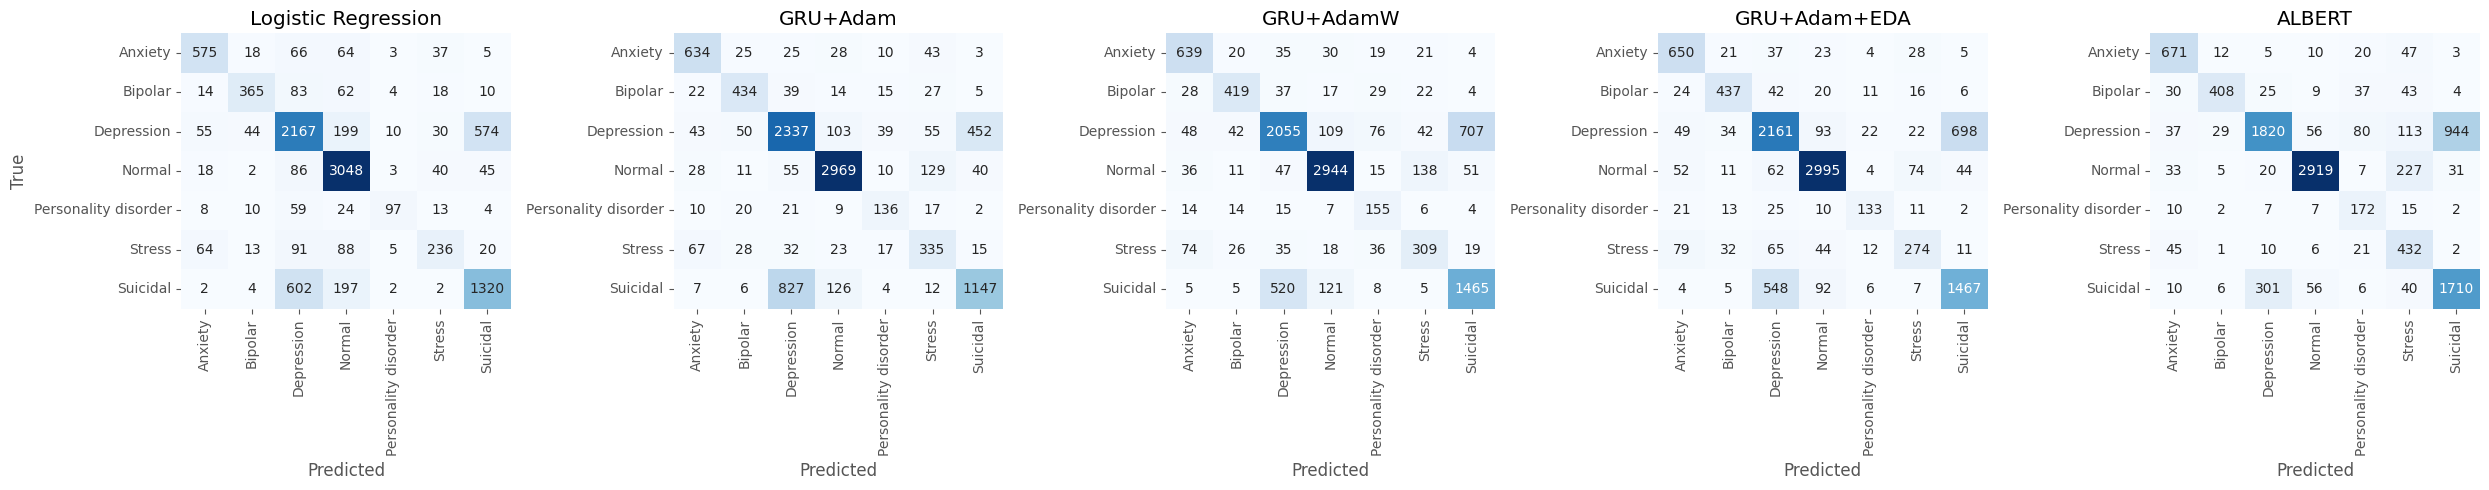

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (model_name, results) in zip(axes, model_results.items()):
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "all_models_confusion_matrices.png"), bbox_inches='tight')
plt.show()



In [72]:
# Identify the most-confused class pairs across all 5 models, not just one.
print("Most confused class pairs per model (excluding the diagonal):\n")
for model_name, results in model_results.items():
    cm = results['confusion_matrix']
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    max_idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    true_cls, pred_cls = CLASS_NAMES[max_idx[0]], CLASS_NAMES[max_idx[1]]
    count = cm_no_diag[max_idx]
    print(f"{model_name:25s}: '{true_cls}' most often mistaken for '{pred_cls}' ({count} cases)")

Most confused class pairs per model (excluding the diagonal):

Logistic Regression      : 'Suicidal' most often mistaken for 'Depression' (602 cases)
GRU+Adam                 : 'Suicidal' most often mistaken for 'Depression' (827 cases)
GRU+AdamW                : 'Depression' most often mistaken for 'Suicidal' (707 cases)
GRU+Adam+EDA             : 'Depression' most often mistaken for 'Suicidal' (698 cases)
ALBERT                   : 'Depression' most often mistaken for 'Suicidal' (944 cases)
